# Blind-user CAPTCHA study: reproducible analysis

This notebook executes the checked analysis script, then displays the exact cohort, quality, inferential, and figure outputs used in the technical report. The Excel source is read-only.

In [1]:
from pathlib import Path
import os, subprocess, sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path('/Users/vaibhav_joshi/Desktop/Scholar Projects/reasoning_captcha/touchstone-collect')
INPUT = Path('/Users/vaibhav_joshi/Downloads/Rohan.xlsx')
ANALYSIS_DIR = PROJECT_ROOT / 'analysis/rohan_study_report'
OUTPUT = ANALYSIS_DIR / 'output'
assert INPUT.exists(), 'Update INPUT to the location of Rohan.xlsx'
OUTPUT.mkdir(parents=True, exist_ok=True)

## Analysis specification

The primary unit is one participant session. Repeated trial keys are resolved with a deterministic earliest-record rule. A paired-complete session must contain six unique prototype trials and one baseline trial. The primary binary comparison uses exact McNemar inference. Five paired ordinal ratings use exact sign-randomized signed-rank tests with Holm family-wise correction.

In [2]:
env = os.environ.copy()
env.update({'MPLBACKEND': 'Agg', 'MPLCONFIGDIR': '/tmp/touchstone-mpl', 'XDG_CACHE_HOME': '/tmp/touchstone-cache'})
run = subprocess.run([sys.executable, str(ANALYSIS_DIR / 'analyze_study.py'), '--input', str(INPUT), '--output', str(OUTPUT)], cwd=PROJECT_ROOT, env=env, text=True, capture_output=True, check=True)
print(run.stdout)

{
  "source_file": "Rohan.xlsx",
  "source_sheet": "Supabase Snippet Untitled query",
  "collection_window_utc": [
    "2026-08-11 08:00:39.329413+00:00",
    "2026-08-26 10:24:56.942527+00:00"
  ],
  "raw_rows": 130,
  "clean_unique_rows": 127,
  "participants": 21,
  "sessions": 21,
  "paired_complete_n": 16,
  "paired_ratings_n": 15,
  "grid_sessions_n": 18,
  "baseline_sessions_n": 19,
  "duplicate_extra_rows": 3,
  "duplicate_sessions": 2,
  "profile_onset_age_inconsistent_n": 8,
  "paired_outcomes": {
    "paired_n": 16.0,
    "prototype_all_six_successes": 12.0,
    "baseline_successes": 4.0,
    "paired_difference_percentage_points": 50.0,
    "bootstrap_95ci_low_pp": 18.75,
    "bootstrap_95ci_high_pp": 81.25,
    "prototype_only_success": 9.0,
    "baseline_only_success": 1.0,
    "both_success": 3.0,
    "neither_success": 3.0,
    "mcnemar_exact_two_sided_p": 0.021484375
  },
  "rating_comparisons": [
    {
      "measure": "difficulty_rating",
      "label": "Difficulty",


## Cohort flow and data quality

In [3]:
display(pd.read_csv(OUTPUT / 'sample_flow.csv'))
display(pd.read_csv(OUTPUT / 'data_quality_summary.csv'))
display(pd.read_csv(OUTPUT / 'profile_consistency.csv'))

,stage,n
0,participant sessions in workbook,21
1,raw trial rows,130
2,unique trial rows after earliest-record rule,127
3,sessions with six prototype trials,18
4,sessions with one baseline trial,19
5,paired-complete sessions,16
6,paired sessions with both condition ratings,15
7,sessions containing repeated submissions,2


,check,value
0,raw_rows,130
1,unique_trial_pk,130
2,participant_ids,21
3,session_ids,21
4,duplicate_extra_rows,3
5,duplicate_sessions,2
6,excluded_rows,0
7,clock_suspect_rows,0
8,tab_away_rows,1
9,blank_trial_id_rows,130


,check,consistent_n,inconsistent_n,denominator,inconsistent_percent
0,blindness onset category agrees with reported ...,13,8,21,38.095238


## Primary paired task-success result

,paired_n,prototype_all_six_successes,baseline_successes,paired_difference_percentage_points,bootstrap_95ci_low_pp,bootstrap_95ci_high_pp,prototype_only_success,baseline_only_success,both_success,neither_success,mcnemar_exact_two_sided_p
0,16,12,4,50.0,18.75,81.25,9,1,3,3,0.021484


,analysis,paired_n,prototype_all_six_successes,baseline_successes,prototype_only_success,baseline_only_success,mcnemar_exact_two_sided_p
0,exclude sessions with repeated submissions,14,11,2,9,0,0.003906


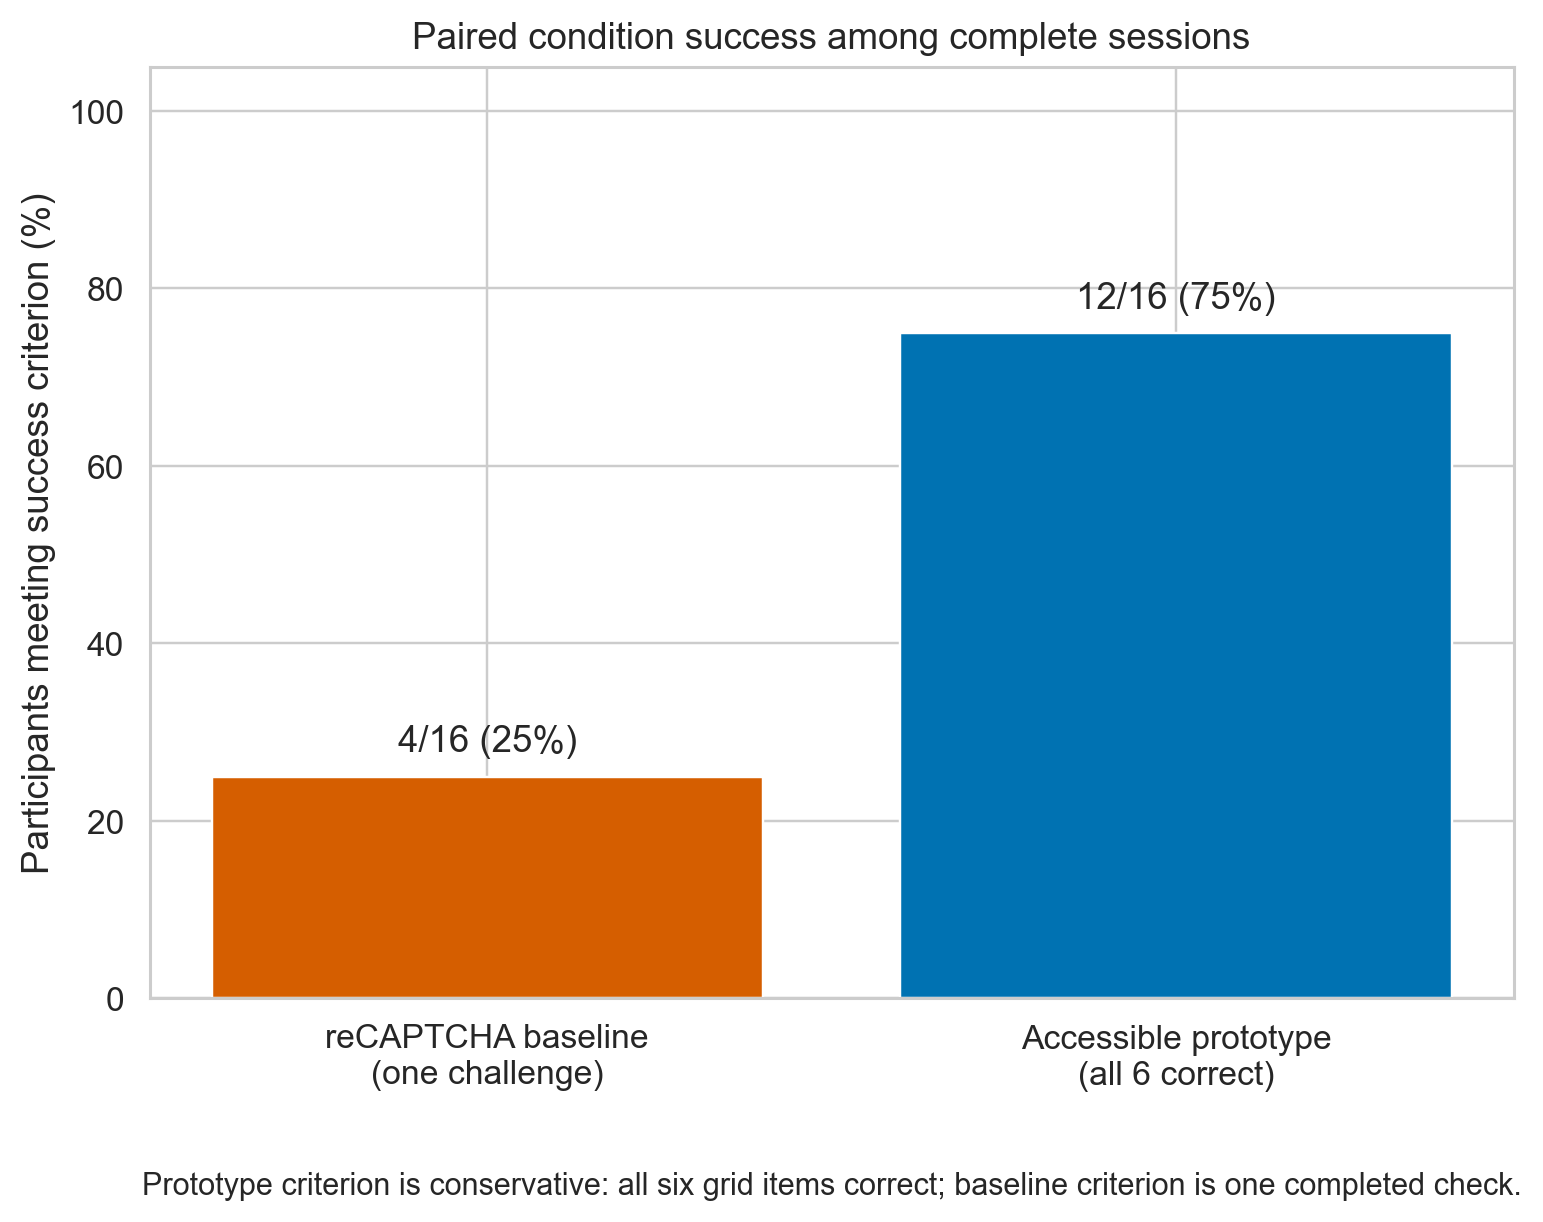

In [4]:
display(pd.read_csv(OUTPUT / 'paired_outcomes.csv'))
display(pd.read_csv(OUTPUT / 'sensitivity_summary.csv'))
display(Image(filename=str(OUTPUT / 'figure_1_paired_success.png')))

## Paired subjective ratings

,measure,label,paired_n,baseline_median,baseline_q1,baseline_q3,prototype_median,prototype_q1,prototype_q3,median_improvement,bootstrap_95ci_low,bootstrap_95ci_high,nonzero_pairs,exact_signed_rank_p,rank_biserial_favoring_prototype,holm_adjusted_p,holm_significant_0_05
0,difficulty_rating,Difficulty,15,3.0,2.0,3.5,2.0,1.0,3.0,1.0,0.95,1.0,15,0.312195,0.300000,1.000000,False
1,mental_effort,Mental effort,15,2.0,1.5,3.5,3.0,2.0,3.0,0.0,-1.00,1.0,13,0.988037,0.021978,1.000000,False
2,frustration,Frustration,15,1.0,1.0,3.0,1.0,1.0,3.0,0.0,0.00,2.0,7,0.281250,0.500000,1.000000,False
3,perceived_accessibility,Perceived accessibility,15,3.0,2.0,3.0,3.0,2.5,3.0,0.0,0.00,1.0,8,0.179688,0.611111,0.898438,False
4,ease_of_navigation,Ease of navigation,15,3.0,2.0,3.0,3.0,2.0,3.5,0.0,-1.00,1.0,12,0.693848,0.153846,1.000000,False


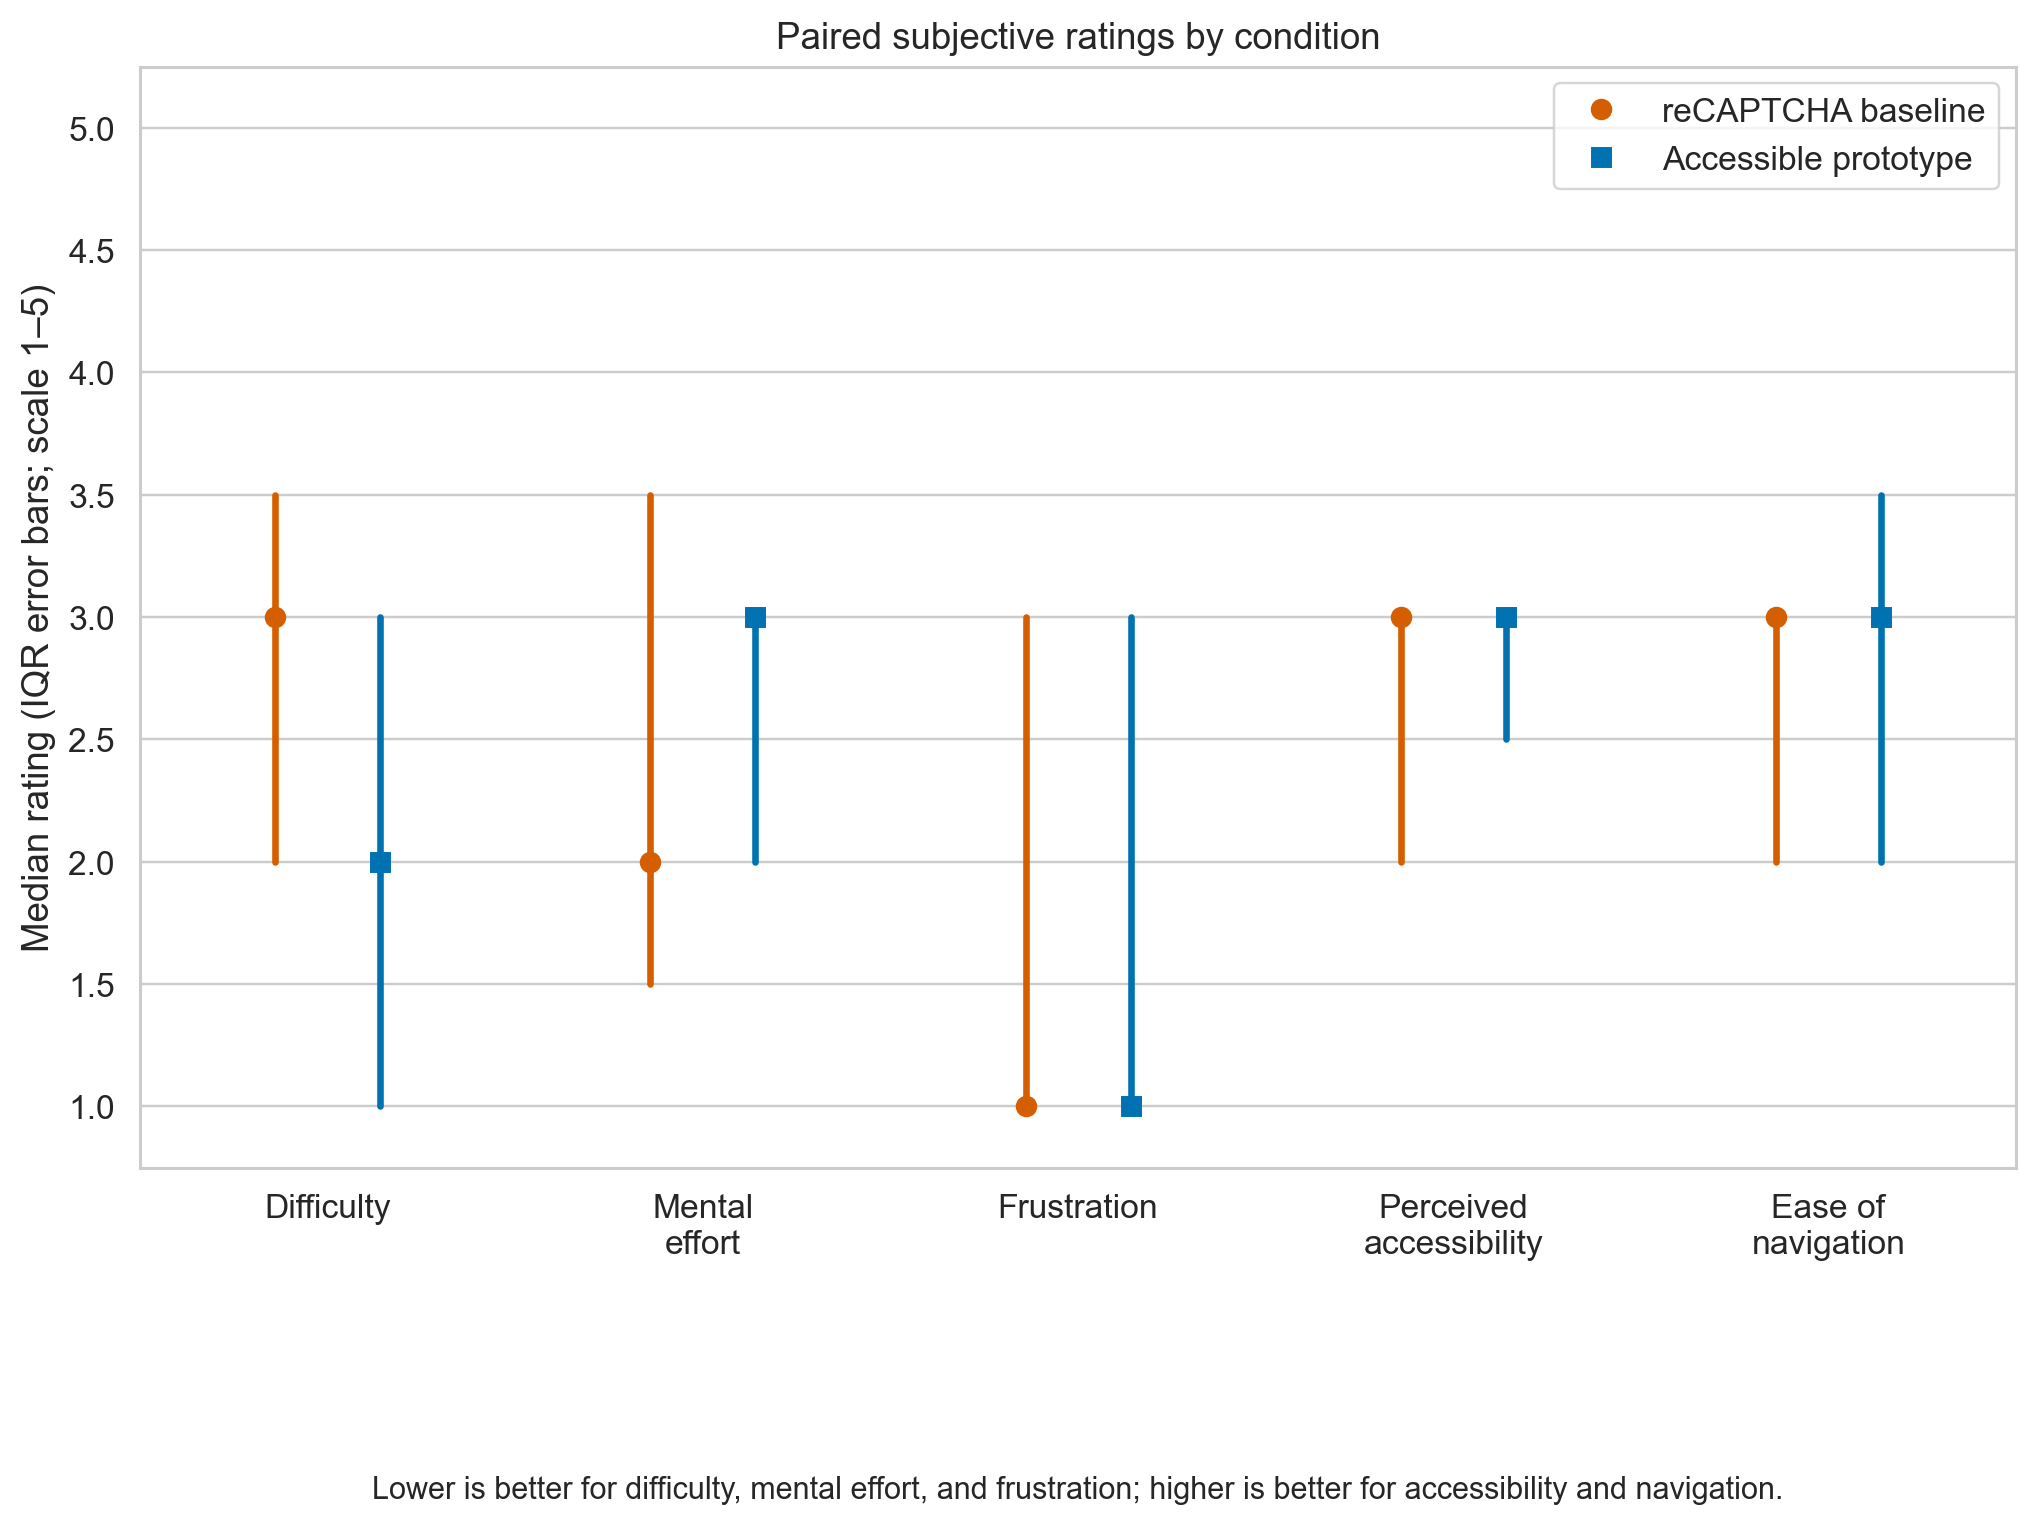

In [5]:
display(pd.read_csv(OUTPUT / 'rating_comparisons.csv'))
display(Image(filename=str(OUTPUT / 'figure_2_paired_ratings.png')))

## Prototype instance performance

,instance_id,trials,correct,gave_up,median_time_s,q1_time_s,q3_time_s,median_orientation_s,median_execution_s,mean_attempts,correct_percent
0,I0009,18,17,1,66.1080,49.75275,78.10600,51.8875,8.9150,1.000000,94.444444
1,I0010,18,17,1,37.9670,30.39625,68.52300,33.4190,8.9110,1.055556,94.444444
2,I0011,18,18,0,69.3285,48.46200,128.64675,52.9885,7.5385,1.222222,100.000000
3,I0012,18,18,0,108.6365,50.65000,144.15700,67.1800,18.6825,1.444444,100.000000
4,I0013,18,16,0,68.1240,48.36275,101.14200,52.7400,8.5420,1.500000,88.888889
5,I0014,18,17,0,108.0355,85.95675,191.20200,86.6295,5.9005,1.500000,94.444444


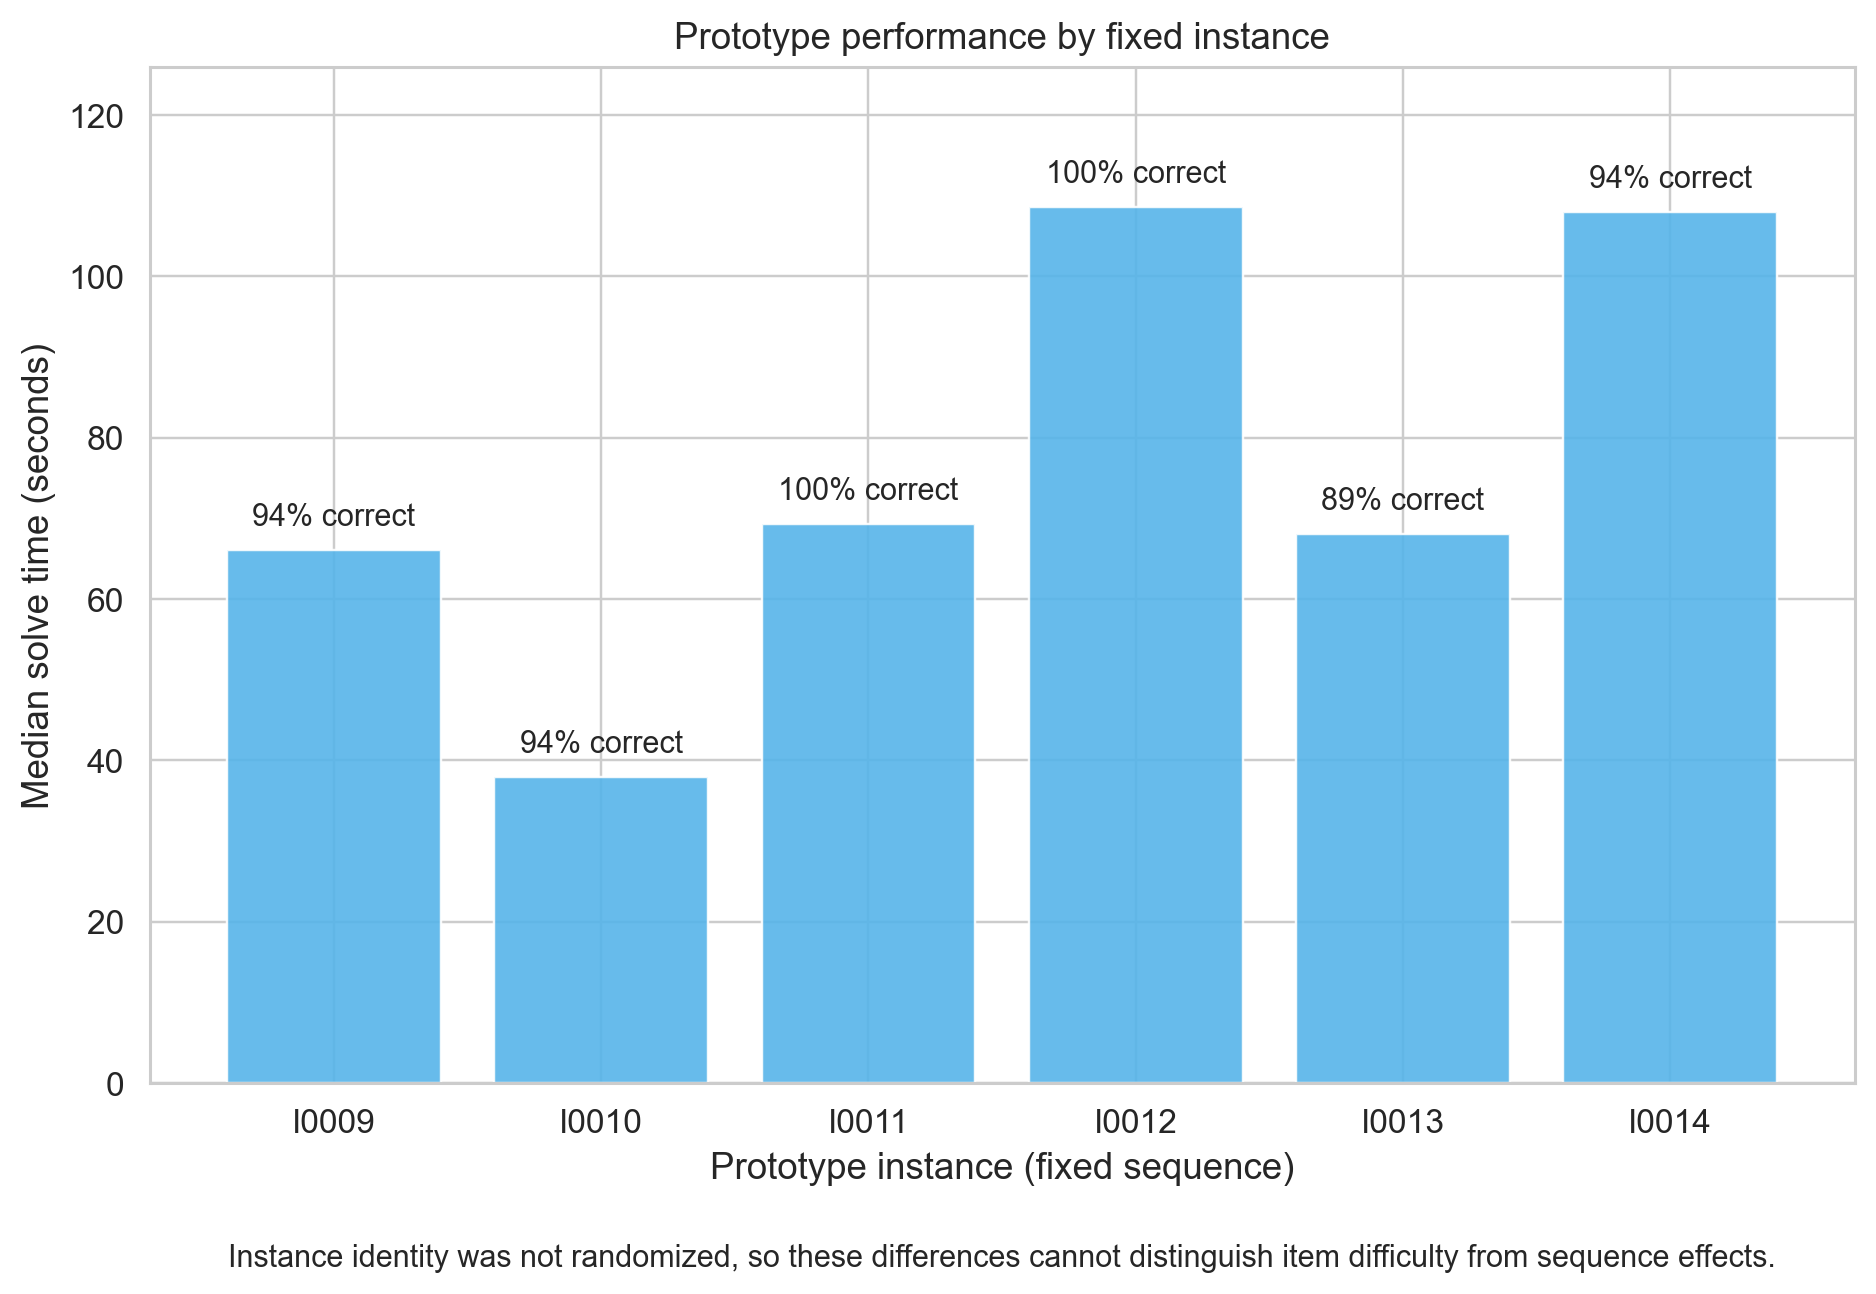

In [6]:
display(pd.read_csv(OUTPUT / 'instance_summary.csv'))
display(Image(filename=str(OUTPUT / 'figure_3_instance_performance.png')))

## Participant characteristics and order diagnostics

In [7]:
display(pd.read_csv(OUTPUT / 'demographic_summary.csv'))
display(pd.read_csv(OUTPUT / 'order_effects.csv'))

,variable,category,n,percent,denominator
0,blindness_onset,congenital,15,71.428571,21
1,blindness_onset,early_onset,4,19.047619,21
2,blindness_onset,prefer_not_to_say,2,9.523810,21
3,age_at_vision_loss,from_birth,9,42.857143,21
4,age_at_vision_loss,age_1_5,8,38.095238,21
5,age_at_vision_loss,prefer_not_to_say,2,9.523810,21
6,age_at_vision_loss,age_13_17,1,4.761905,21
7,age_at_vision_loss,age_6_12,1,4.761905,21
8,primary_language,hindi,11,52.380952,21
9,primary_language,other,9,42.857143,21


,analysis,statistic,p_value
0,paired completion by block order,0.857143,1.000000
1,prototype median item time by block order,29.000000,0.331387


## Interpretation guardrails

The six prototype trials and the single baseline challenge are not matched in task content or workload. Therefore, solve-time values are descriptive and not treated as a causal speed comparison. The workbook lacks the baseline `challenge_shown` flag and trial notes, so successful checkbox-only responses cannot be separated from actual audio challenges. The grid task measures performance on the implemented elimination puzzles; it is not a validated general reasoning-ability instrument.